In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load and analyze dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("Number of Training Images:", x_train.shape[0])
print("Number of Test Images:", x_test.shape[0])
print("Image Dimensions:", x_train.shape[1:])

Number of Training Images: 60000
Number of Test Images: 10000
Image Dimensions: (28, 28)


In [3]:
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
# Pre Processing Data

# 1. Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2. Reshape images for CNN (60000, 28, 28) -> (60000, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
print("Training Shape:", x_train.shape)
print("Test Shape:", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)


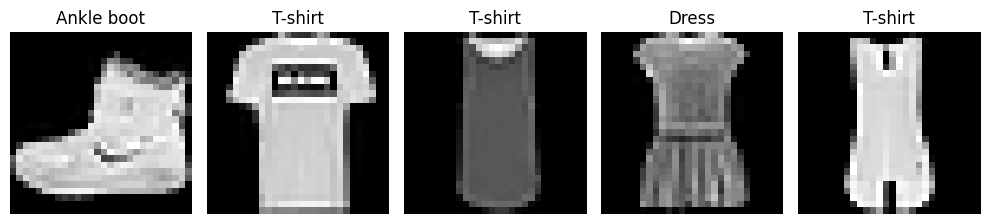

In [6]:
# Visualizing Data

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Build the model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Convolution Layer
    Conv2D(
        filters=32,
         kernel_size=(3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),
    # First Max Pooling Layer
    MaxPooling2D((2, 2)),
    # Second Convolution Layer
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),
    # Second Max Pooling Layer
    MaxPooling2D((2, 2)),
    # Flatten Layer
    Flatten(),
    # Dense Hidden Layer
    Dense(128, activation='relu'),
    # Output Layer
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compiling the model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
# Training the model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

print(history.history.keys())

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.8271 - loss: 0.4770 - val_accuracy: 0.8669 - val_loss: 0.3714
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8849 - loss: 0.3164 - val_accuracy: 0.8944 - val_loss: 0.2989
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9010 - loss: 0.2698 - val_accuracy: 0.8999 - val_loss: 0.2744
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9139 - loss: 0.2363 - val_accuracy: 0.9031 - val_loss: 0.2672
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9231 - loss: 0.2093 - val_accuracy: 0.9085 - val_loss: 0.2503
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9314 - loss: 0.1849 - val_accuracy: 0.9051 - val_loss: 0.2588
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9372 - loss: 0.1659 - val_accuracy: 0.9125 - val_loss: 0.2528
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9463 -

Final Training Accuracy: 95.74 %
Final Validation Accuracy: 91.26 %


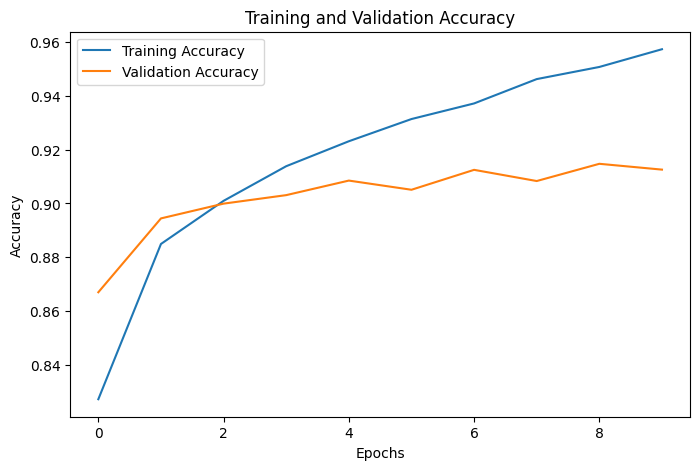

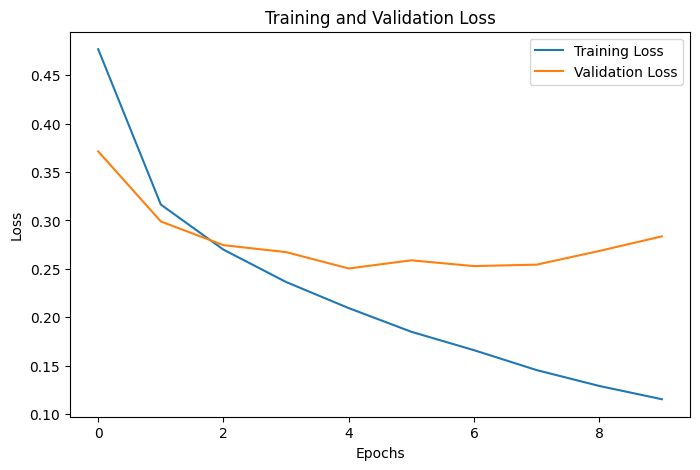

In [10]:
# Training Accuracy Stats and Plots

final_train_accuracy = history.history['accuracy'][-1]
print("Final Training Accuracy:", round(final_train_accuracy * 100, 2), "%")

final_val_accuracy = history.history['val_accuracy'][-1]
print("Final Validation Accuracy:", round(final_val_accuracy * 100, 2), "%")

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [12]:
# The model was trained for 10 epochs using batch size of 32. The training accuracy
# reached 95.74%, while the validation accuracy reached 91.26%.

In [13]:
# Model Evaluation

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9069 - loss: 0.3153
Test Accuracy: 90.69 %
Test Loss: 0.3153


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


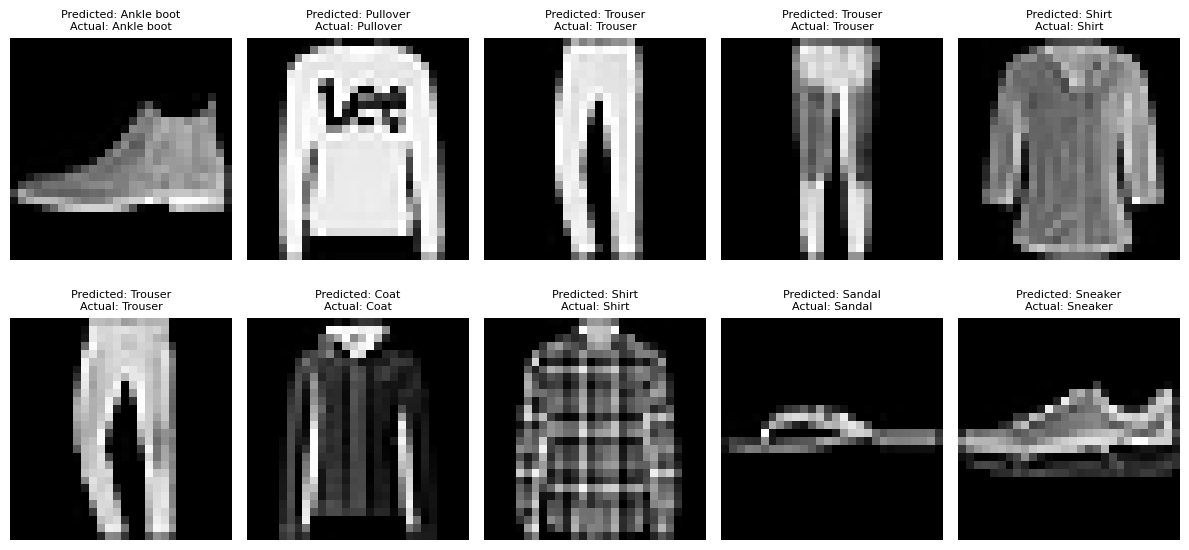

In [14]:
# Generate and display predictions

predictions = model.predict(x_test)
predicted_labels = predictions.argmax(axis=1)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    predicted = class_names[predicted_labels[i]]
    actual = class_names[y_test[i]]
    plt.title(f"Predicted: {predicted}\nActual: {actual}", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

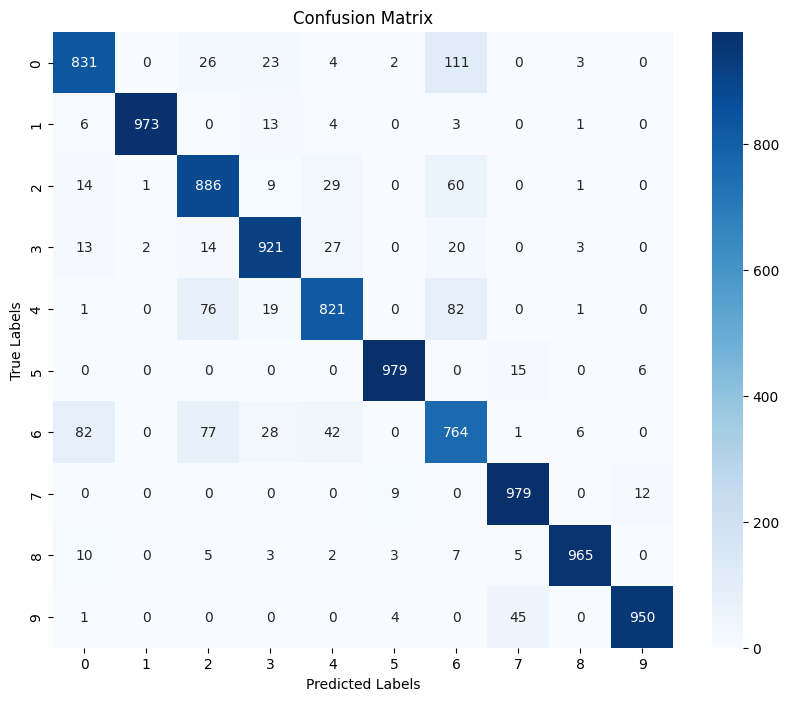

In [16]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title("Confusion Matrix")
plt.show()

In [17]:
# Classification Report
from sklearn.metrics import classification_report

class_report = classification_report(y_test, predicted_labels, target_names=class_names)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.87      0.83      0.85      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.82      0.89      0.85      1000
       Dress       0.91      0.92      0.91      1000
        Coat       0.88      0.82      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.73      0.76      0.75      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [18]:
# Model Analysis

# 1. Why CNNs are better for image than ANNs?
# CNNs are very good at extracting spatial features (edges, textures, shapes etc)

# 2. Purpose of Convlution Layer?
# Applies kernels to extract spatial features like edges, shapes, corners, patterns etc
# Deeper convoltuion layer extract more complex structures

# 3. Why Max Pooling?
# To reduce spatial dimension of feature maps

# 4. Why Flatten before Dense?
# Dense layer require one-dimensional input

# 5. Why softmax in output?
# Convert probablities into values

# 6. Benefit of Adam Optimizer?
# Auto adjust learnign rate during training for fast convergance